# LSTM Skeleton Baseline (Colab)

Baseline LSTM for skeleton-based action recognition using pre-extracted HRNet 2D keypoints.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Cell 1: Imports
import os
import math
import pickle
import random
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt


In [3]:
# Cell 2: Seed and device
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [ ]:
# Cell 3: Path to your pkl file and quick inspection
PKL_PATH = "/content/drive/MyDrive/ntu60_hrnet.pkl"

with open(PKL_PATH, "rb") as f:
    data = pickle.load(f)

print(type(data))
print(data.keys())

annotations = data["annotations"]
split = data["split"]

print("Number of samples:", len(annotations))
print("Split keys:", split.keys())

sample_ann = annotations[0]
print("Annotation keys:", sample_ann.keys())
print("Sample label:", sample_ann["label"])
print("Sample keypoint shape:", sample_ann["keypoint"].shape)

if "keypoint_score" in sample_ann:
    print("Sample keypoint_score shape:", sample_ann["keypoint_score"].shape)


<class 'dict'>
dict_keys(['split', 'annotations'])
Number of samples: 56578
Split keys: dict_keys(['xsub_train', 'xsub_val', 'xview_train', 'xview_val'])
Annotation keys: dict_keys(['frame_dir', 'label', 'img_shape', 'original_shape', 'total_frames', 'keypoint', 'keypoint_score'])
Sample label: 0
Sample keypoint shape: (1, 103, 17, 2)
Sample keypoint_score shape: (1, 103, 17)


In [ ]:
# Cell 4: Build index from split names to annotation indices
frame_dir_to_idx = {}
for i, ann in enumerate(annotations):
    frame_dir_to_idx[ann["frame_dir"]] = i

# dùng xsub
train_indices = [frame_dir_to_idx[name] for name in split["xsub_train"]]
val_indices = [frame_dir_to_idx[name] for name in split["xsub_val"]]

print("Train samples:", len(train_indices))
print("Val samples:", len(val_indices))


Train samples: 40091
Val samples: 16487


In [6]:
# Cell 5: Hyperparameters
NUM_CLASSES = 60
MAX_FRAMES = 100
NUM_PERSON = 2
USE_SCORE = False

BATCH_SIZE = 64
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2

HIDDEN_SIZE = 256
NUM_LAYERS = 2
DROPOUT = 0.5
BIDIRECTIONAL = False


In [7]:
# Cell 6: Utility functions for preprocessing
def resize_time_axis(seq, target_len=100):
    """
    seq: numpy array shape (C, T, V)
    output: (C, target_len, V)
    """
    C, T, V = seq.shape
    if T == target_len:
        return seq.astype(np.float32)

    old_idx = np.linspace(0, T - 1, num=T)
    new_idx = np.linspace(0, T - 1, num=target_len)

    out = np.zeros((C, target_len, V), dtype=np.float32)
    for c in range(C):
        for v in range(V):
            out[c, :, v] = np.interp(new_idx, old_idx, seq[c, :, v])
    return out


def select_top_persons(keypoint, keypoint_score=None, max_person=2):
    """
    keypoint: (M, T, V, 2)
    keypoint_score: (M, T, V) or None
    """
    M = keypoint.shape[0]
    if M <= max_person:
        return keypoint, keypoint_score

    if keypoint_score is not None:
        person_scores = keypoint_score.sum(axis=(1, 2))
    else:
        person_scores = np.abs(keypoint).sum(axis=(1, 2, 3))

    top_idx = np.argsort(person_scores)[::-1][:max_person]
    keypoint_sel = keypoint[top_idx]

    if keypoint_score is not None:
        score_sel = keypoint_score[top_idx]
    else:
        score_sel = None

    return keypoint_sel, score_sel


def build_lstm_input(
    keypoint,
    keypoint_score=None,
    max_frames=100,
    num_person=2,
    use_score=False,
):
    """
    keypoint: (M, T, V, 2)
    keypoint_score: (M, T, V) or None

    output:
        x_seq: (T, F)
        F = num_person * V * C
    """
    keypoint, keypoint_score = select_top_persons(
        keypoint=keypoint,
        keypoint_score=keypoint_score,
        max_person=num_person
    )

    M, T, V, _ = keypoint.shape
    C = 3 if (use_score and keypoint_score is not None) else 2

    out = np.zeros((num_person, C, max_frames, V), dtype=np.float32)

    for m in range(min(M, num_person)):
        xy = keypoint[m].transpose(2, 0, 1).astype(np.float32)   # (2, T, V)
        xy = resize_time_axis(xy, target_len=max_frames)         # (2, max_frames, V)

        if C == 3:
            sc = keypoint_score[m][None, ...].astype(np.float32) # (1, T, V)
            sc = resize_time_axis(sc, target_len=max_frames)     # (1, max_frames, V)
            feat = np.concatenate([xy, sc], axis=0)              # (3, max_frames, V)
        else:
            feat = xy

        out[m] = feat

    # (M, C, T, V) -> (T, M, C, V)
    out = np.transpose(out, (2, 0, 1, 3))

    # flatten mỗi frame thành vector
    x_seq = out.reshape(max_frames, -1).astype(np.float32)       # (T, F)
    return x_seq


In [8]:
# Cell 7: Dataset
class NTUSkeletonLSTMDataset(Dataset):
    def __init__(
        self,
        annotations,
        indices,
        max_frames=100,
        num_person=2,
        use_score=False,
        mean=None,
        std=None,
    ):
        self.annotations = annotations
        self.indices = indices
        self.max_frames = max_frames
        self.num_person = num_person
        self.use_score = use_score
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        ann = self.annotations[self.indices[idx]]

        keypoint = ann["keypoint"]                         # (M, T, V, 2)
        keypoint_score = ann.get("keypoint_score", None)  # (M, T, V)
        label = int(ann["label"])

        x = build_lstm_input(
            keypoint=keypoint,
            keypoint_score=keypoint_score,
            max_frames=self.max_frames,
            num_person=self.num_person,
            use_score=self.use_score,
        )  # (T, F)

        if self.mean is not None and self.std is not None:
            x = (x - self.mean[None, :]) / self.std[None, :]

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(label, dtype=torch.long)
        return x, y


In [9]:
# Cell 8: Build datasets and dataloaders
def compute_mean_std_lstm(dataset_raw):
    sum_x = None
    sum_x2 = None
    total_frames = 0

    for i in range(len(dataset_raw)):
        x, _ = dataset_raw[i]   # x: (T, F)
        x = x.numpy()

        if sum_x is None:
            F = x.shape[1]
            sum_x = np.zeros(F, dtype=np.float64)
            sum_x2 = np.zeros(F, dtype=np.float64)

        sum_x += x.sum(axis=0)
        sum_x2 += (x ** 2).sum(axis=0)
        total_frames += x.shape[0]

    mean = sum_x / total_frames
    var = sum_x2 / total_frames - mean ** 2
    std = np.sqrt(np.maximum(var, 1e-6))

    return mean.astype(np.float32), std.astype(np.float32)


train_dataset_raw = NTUSkeletonLSTMDataset(
    annotations=annotations,
    indices=train_indices,
    max_frames=MAX_FRAMES,
    num_person=NUM_PERSON,
    use_score=USE_SCORE,
    mean=None,
    std=None,
)

mean_lstm, std_lstm = compute_mean_std_lstm(train_dataset_raw)

train_dataset = NTUSkeletonLSTMDataset(
    annotations=annotations,
    indices=train_indices,
    max_frames=MAX_FRAMES,
    num_person=NUM_PERSON,
    use_score=USE_SCORE,
    mean=mean_lstm,
    std=std_lstm,
)

val_dataset = NTUSkeletonLSTMDataset(
    annotations=annotations,
    indices=val_indices,
    max_frames=MAX_FRAMES,
    num_person=NUM_PERSON,
    use_score=USE_SCORE,
    mean=mean_lstm,
    std=std_lstm,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

sample_x, sample_y = train_dataset[0]
print("sample_x shape:", sample_x.shape)   # (T, F)
print("sample_y:", sample_y.item())


sample_x shape: torch.Size([100, 68])
sample_y: 0


In [10]:
# Cell 9: LSTM model
class LSTMClassifier(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=256,
        num_layers=2,
        num_classes=60,
        dropout=0.5,
        bidirectional=False,
    ):
        super().__init__()

        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * self.num_directions, num_classes)

    def forward(self, x):
        """
        x: (B, T, F)
        """
        out, (h_n, c_n) = self.lstm(x)

        if self.bidirectional:
            h_last = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            h_last = h_n[-1]

        h_last = self.dropout(h_last)
        logits = self.fc(h_last)
        return logits


input_dim = sample_x.shape[1]

model = LSTMClassifier(
    input_size=input_dim,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
    bidirectional=BIDIRECTIONAL,
).to(device)

print(model)


LSTMClassifier(
  (lstm): LSTM(68, 256, num_layers=2, batch_first=True, dropout=0.5)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=60, bias=True)
)


In [11]:
# Cell 10: Training and evaluation functions
def compute_accuracy(logits, targets):
    preds = torch.argmax(logits, dim=1)
    correct = (preds == targets).sum().item()
    total = targets.size(0)
    return correct / total


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    total_batches = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        acc = compute_accuracy(logits, y)

        running_loss += loss.item()
        running_acc += acc
        total_batches += 1

    return running_loss / total_batches, running_acc / total_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    total_batches = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)
        acc = compute_accuracy(logits, y)

        running_loss += loss.item()
        running_acc += acc
        total_batches += 1

    return running_loss / total_batches, running_acc / total_batches


In [12]:
# Cell 11: Train
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

best_val_acc = 0.0
SAVE_DIR = "/content/drive/MyDrive/skeleton_project_outputs/lstm"
os.makedirs(SAVE_DIR, exist_ok=True)
best_model_path = os.path.join(SAVE_DIR, "best_lstm.pth")

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

print("Best val acc:", best_val_acc)
print("Best model saved to:", best_model_path)

history_path = os.path.join(SAVE_DIR, "training_history_lstm.csv")
try:
    import pandas as pd
    pd.DataFrame(history).to_csv(history_path, index=False)
except ImportError:
    import csv
    with open(history_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["train_loss", "train_acc", "val_loss", "val_acc"])
        writer.writerows(zip(
            history["train_loss"],
            history["train_acc"],
            history["val_loss"],
            history["val_acc"],
        ))
print("history saved to:", history_path)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01/20 | train_loss=3.0049 train_acc=0.1412 | val_loss=2.5812 val_acc=0.2170
Epoch 02/20 | train_loss=2.3675 train_acc=0.2716 | val_loss=2.1952 val_acc=0.3336
Epoch 03/20 | train_loss=1.9751 train_acc=0.3684 | val_loss=1.9265 val_acc=0.3866
Epoch 04/20 | train_loss=1.8169 train_acc=0.4112 | val_loss=1.7515 val_acc=0.4437
Epoch 05/20 | train_loss=1.6695 train_acc=0.4538 | val_loss=1.7624 val_acc=0.4335
Epoch 06/20 | train_loss=1.5459 train_acc=0.4905 | val_loss=1.5048 val_acc=0.5165
Epoch 07/20 | train_loss=1.4375 train_acc=0.5206 | val_loss=1.4432 val_acc=0.5367
Epoch 08/20 | train_loss=1.3486 train_acc=0.5560 | val_loss=1.3475 val_acc=0.5654
Epoch 09/20 | train_loss=1.2539 train_acc=0.5850 | val_loss=1.4316 val_acc=0.5422
Epoch 10/20 | train_loss=1.2059 train_acc=0.6019 | val_loss=1.2834 val_acc=0.6025
Epoch 11/20 | train_loss=1.1448 train_acc=0.6188 | val_loss=1.2362 val_acc=0.6123
Epoch 12/20 | train_loss=1.0808 train_acc=0.6427 | val_loss=1.1916 val_acc=0.6258
Epoch 13/20 | tr

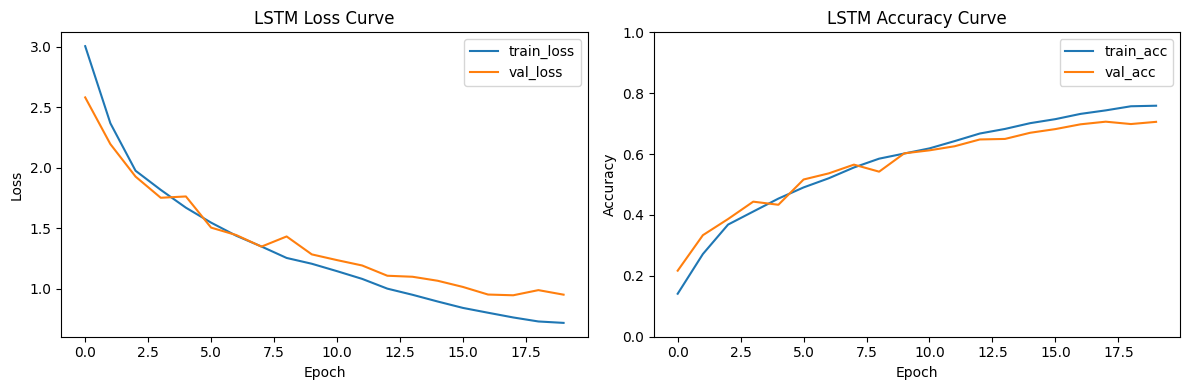

training curves saved to: /content/drive/MyDrive/skeleton_project_outputs/lstm/training_curves_lstm.png


In [13]:
# Plot training curves and save figure
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Accuracy Curve")
plt.ylim(0.0, 1.0)
plt.legend()

plt.tight_layout()
curve_path = os.path.join(SAVE_DIR, "training_curves_lstm.png")
plt.savefig(curve_path, dpi=300, bbox_inches="tight")
plt.show()
print("training curves saved to:", curve_path)


In [14]:
# Cell 11: Load best model and inspect predictions with class names
import pandas as pd
import numpy as np
import torch

ntu60_class_names = [
    "drink water",
    "eat meal",
    "brush teeth",
    "brush hair",
    "drop",
    "pick up",
    "throw",
    "sit down",
    "stand up",
    "clapping",
    "reading",
    "writing",
    "tear up paper",
    "put on jacket",
    "take off jacket",
    "put on a shoe",
    "take off a shoe",
    "put on glasses",
    "take off glasses",
    "put on a hat/cap",
    "take off a hat/cap",
    "cheer up",
    "hand waving",
    "kicking something",
    "reach into pocket",
    "hopping",
    "jump up",
    "phone call",
    "play with phone/tablet",
    "type on a keyboard",
    "point to something",
    "taking a selfie",
    "check time (from watch)",
    "rub two hands",
    "nod head/bow",
    "shake head",
    "wipe face",
    "salute",
    "put palms together",
    "cross hands in front",
    "sneeze/cough",
    "staggering",
    "falling down",
    "headache",
    "chest pain",
    "back pain",
    "neck pain",
    "nausea/vomiting",
    "fan self",
    "punch/slap",
    "kicking",
    "pushing",
    "pat on back",
    "point finger",
    "hugging",
    "giving object",
    "touch pocket",
    "shaking hands",
    "walking towards",
    "walking apart"
]

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

x_batch, y_batch = next(iter(val_loader))
x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

with torch.no_grad():
    logits = model(x_batch)
    preds = logits.argmax(dim=1)

true_ids = y_batch.cpu().numpy()
pred_ids = preds.cpu().numpy()

num_show = min(20, len(true_ids))

df_pred = pd.DataFrame({
    "sample_id": np.arange(num_show),
    "true_id": true_ids[:num_show],
    "true_name": [ntu60_class_names[i] for i in true_ids[:num_show]],
    "pred_id": pred_ids[:num_show],
    "pred_name": [ntu60_class_names[i] for i in pred_ids[:num_show]],
    "correct": (true_ids[:num_show] == pred_ids[:num_show])
})

df_pred

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


,sample_id,true_id,true_name,pred_id,pred_name,correct
0,0,0,drink water,0,drink water,True
1,1,1,eat meal,1,eat meal,True
2,2,2,brush teeth,2,brush teeth,True
3,3,3,brush hair,3,brush hair,True
4,4,4,drop,44,chest pain,False
5,5,5,pick up,16,take off a shoe,False
6,6,6,throw,6,throw,True
7,7,7,sit down,7,sit down,True
8,8,8,stand up,8,stand up,True
9,9,9,clapping,33,rub two hands,False


In [15]:
# Confusion analysis setup: collect validation predictions once
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
class_names = globals().get("ntu60_class_names", [str(i) for i in range(cm.shape[0])])
print("num validation samples:", len(all_labels))
print("confusion matrix shape:", cm.shape)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


num validation samples: 16487
confusion matrix shape: (60, 60)


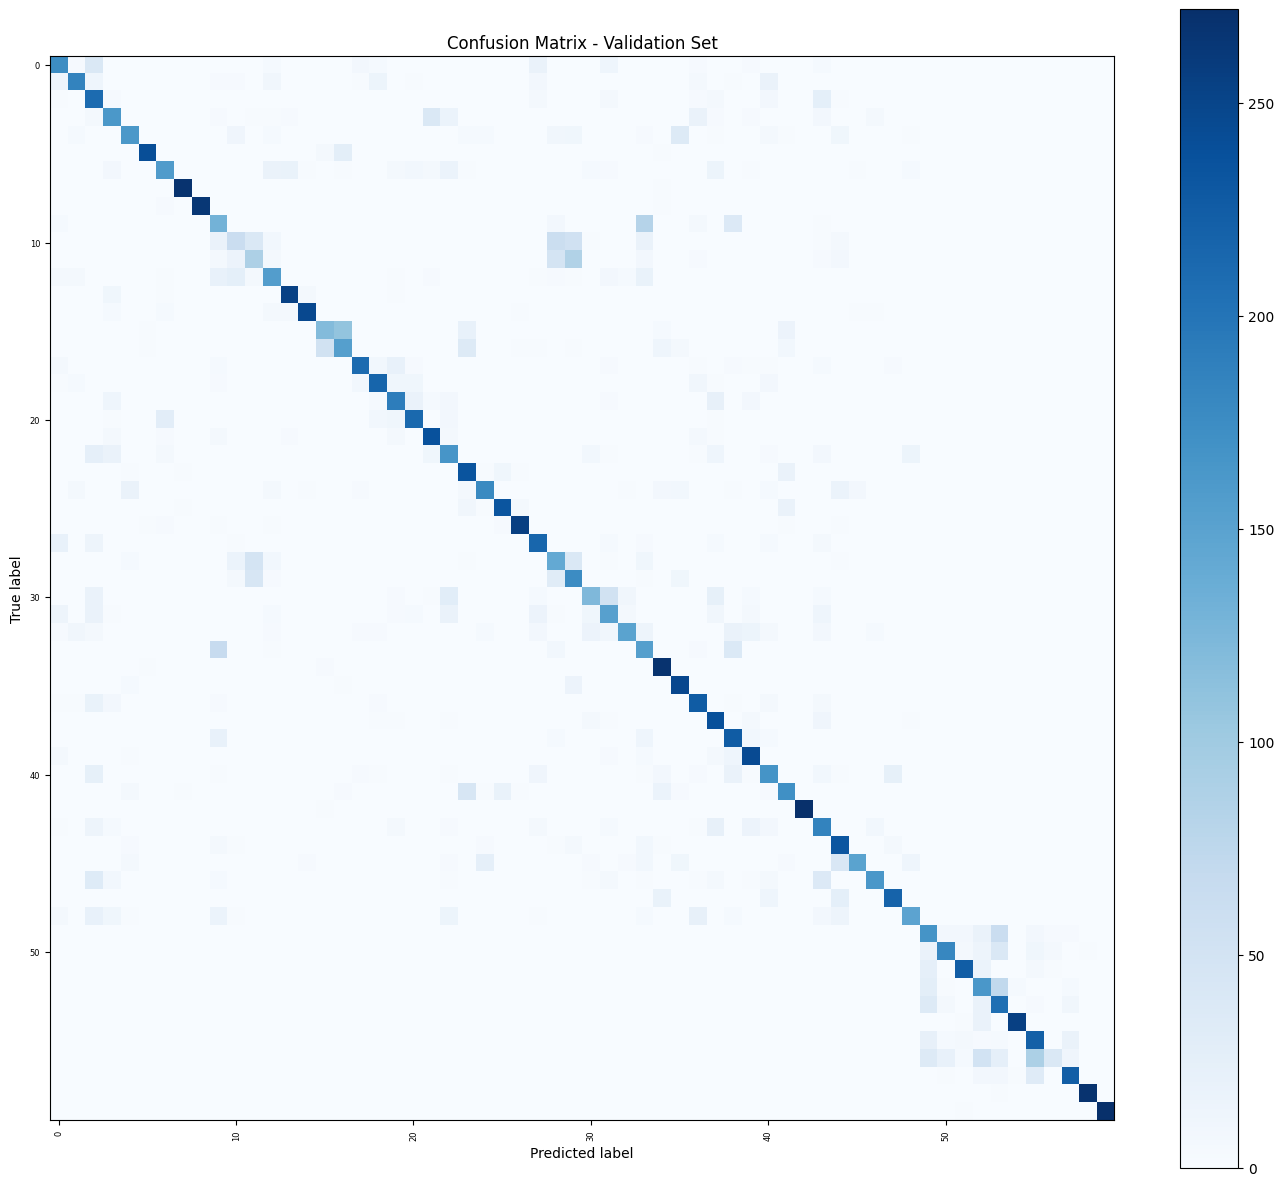

In [16]:
plt.figure(figsize=(14, 12))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix - Validation Set")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.colorbar()

plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=6)

plt.tight_layout()
cm_raw_path = os.path.join(SAVE_DIR, "confusion_matrix_lstm_raw.png")
plt.savefig(cm_raw_path, dpi=300, bbox_inches="tight")
plt.show()


normalized confusion matrix saved to: /content/drive/MyDrive/skeleton_project_outputs/lstm/confusion_matrix_lstm_normalized.png


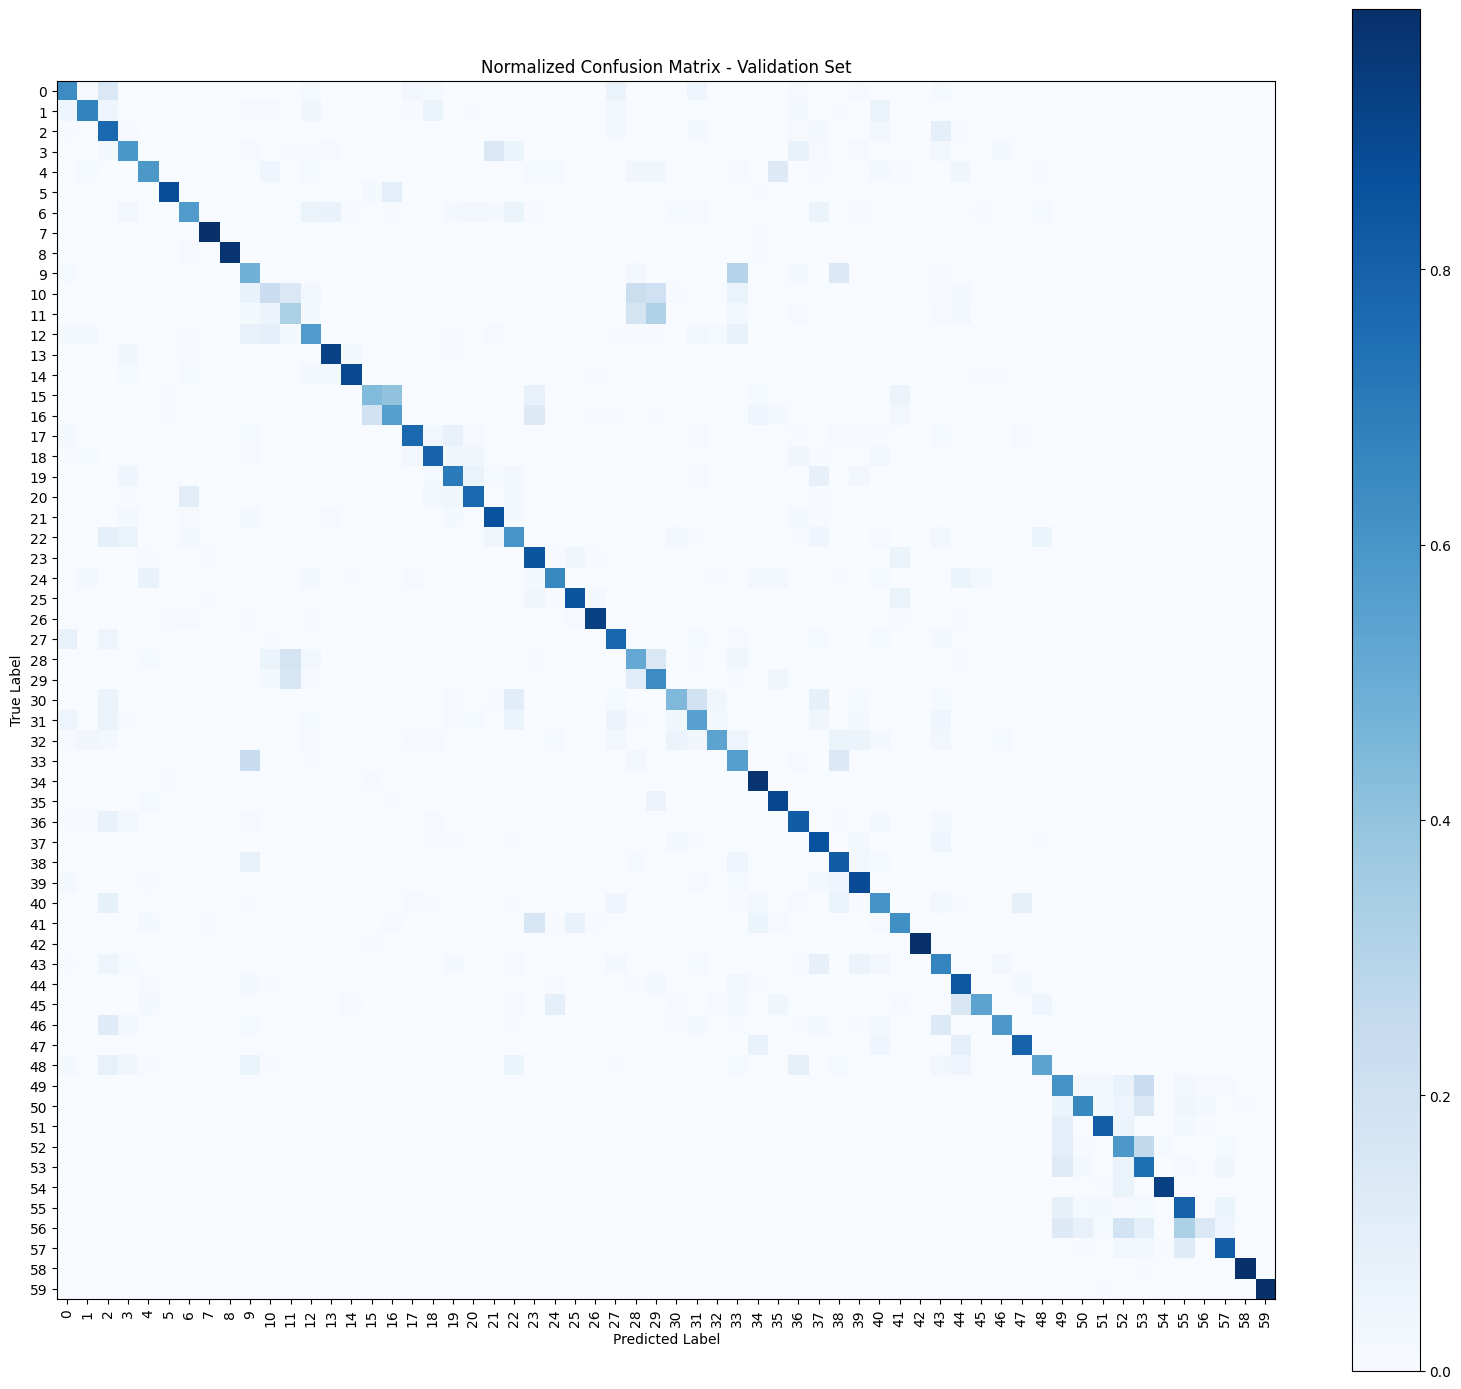

In [17]:
# Save normalized confusion matrix
cm_norm = confusion_matrix(all_labels, all_preds, normalize="true")
fig, ax = plt.subplots(figsize=(16, 14))
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp_norm.plot(
    ax=ax,
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=90,
    colorbar=True,
)

# Hide dense cell labels; the heatmap is easier to read for 60 classes.
for text in disp_norm.text_.ravel():
    text.set_visible(False)

plt.title("Normalized Confusion Matrix - Validation Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
cm_norm_path = os.path.join(SAVE_DIR, "confusion_matrix_lstm_normalized.png")
plt.savefig(cm_norm_path, dpi=300, bbox_inches="tight")
print("normalized confusion matrix saved to:", cm_norm_path)
plt.show()


In [18]:
# Save top confused pairs by raw count
confusions = []

for true_class in range(cm.shape[0]):
    true_total = cm[true_class].sum()
    for pred_class in range(cm.shape[1]):
        count = int(cm[true_class, pred_class])
        if true_class != pred_class and count > 0:
            rate = count / true_total if true_total > 0 else 0.0
            confusions.append({
                "True class": true_class,
                "True name": class_names[true_class] if true_class < len(class_names) else str(true_class),
                "Predicted class": pred_class,
                "Predicted name": class_names[pred_class] if pred_class < len(class_names) else str(pred_class),
                "Count": count,
                "Rate within true class": rate,
            })

confusion_df = pd.DataFrame(confusions)
top_confusions = confusion_df.sort_values(by="Count", ascending=False).head(10)
print(top_confusions)

top_confusions_path = os.path.join(SAVE_DIR, "top_confusions_lstm.csv")
top_confusions.to_csv(top_confusions_path, index=False)
print("top confusions saved to:", top_confusions_path)


     True class           True name  Predicted class          Predicted name  \
193          15       put on a shoe               16         take off a shoe   
676          56        touch pocket               55           giving object   
144          11             writing               29      type on a keyboard   
118           9            clapping               33           rub two hands   
649          52         pat on back               53            point finger   
436          33       rub two hands                9                clapping   
626          49          punch/slap               53            point finger   
128          10             reading               28  play with phone/tablet   
129          10             reading               29      type on a keyboard   
389          30  point to something               31         taking a selfie   

     Count  Rate within true class  
193    109                0.399267  
676     90                0.327273  
144     

In [19]:
# Save top confused pairs by rate within true class
if "confusion_df" not in globals():
    confusions = []
    for true_class in range(cm.shape[0]):
        true_total = cm[true_class].sum()
        for pred_class in range(cm.shape[1]):
            count = int(cm[true_class, pred_class])
            if true_class != pred_class and count > 0:
                rate = count / true_total if true_total > 0 else 0.0
                confusions.append({
                    "True class": true_class,
                    "True name": class_names[true_class] if true_class < len(class_names) else str(true_class),
                    "Predicted class": pred_class,
                    "Predicted name": class_names[pred_class] if pred_class < len(class_names) else str(pred_class),
                    "Count": count,
                    "Rate within true class": rate,
                })
    confusion_df = pd.DataFrame(confusions)

top_confusions_by_rate = confusion_df.sort_values(by="Rate within true class", ascending=False).head(10)
print(top_confusions_by_rate)

top_confusions_rate_path = os.path.join(SAVE_DIR, "top_confusions_lstm_by_rate.csv")
top_confusions_by_rate.to_csv(top_confusions_rate_path, index=False)
print("top confusions by rate saved to:", top_confusions_rate_path)


     True class           True name  Predicted class          Predicted name  \
193          15       put on a shoe               16         take off a shoe   
676          56        touch pocket               55           giving object   
144          11             writing               29      type on a keyboard   
118           9            clapping               33           rub two hands   
649          52         pat on back               53            point finger   
436          33       rub two hands                9                clapping   
626          49          punch/slap               53            point finger   
128          10             reading               28  play with phone/tablet   
129          10             reading               29      type on a keyboard   
389          30  point to something               31         taking a selfie   

     Count  Rate within true class  
193    109                0.399267  
676     90                0.327273  
144     

In [20]:
# Save classification report
report = classification_report(all_labels, all_preds, digits=4)
print(report)

report_path = os.path.join(SAVE_DIR, "classification_report_lstm.txt")
with open(report_path, "w") as f:
    f.write(report)
print("classification report saved to:", report_path)


              precision    recall  f1-score   support

           0     0.6757    0.6387    0.6567       274
           1     0.8178    0.6691    0.7360       275
           2     0.4595    0.7692    0.5753       273
           3     0.6183    0.5934    0.6056       273
           4     0.7642    0.5891    0.6653       275
           5     0.9602    0.8764    0.9163       275
           6     0.7383    0.5745    0.6462       275
           7     0.9710    0.9817    0.9763       273
           8     0.9925    0.9670    0.9796       273
           9     0.4127    0.4762    0.4422       273
          10     0.4189    0.2271    0.2945       273
          11     0.3886    0.3272    0.3553       272
          12     0.6367    0.5756    0.6047       271
          13     0.8877    0.9200    0.9036       275
          14     0.9213    0.8913    0.9061       276
          15     0.6486    0.4396    0.5240       273
          16     0.5117    0.5584    0.5340       274
          17     0.8861    